In [1]:
import pandas as pd
import numpy as np

In [2]:
tenders = pd.read_csv(r'/Users/saurabhlevin/Deployment/IDS-DRR_Heat/Heat-odisha/data_extractor/TENDERS/data/heattenders_districtgeotagged.csv')


In [3]:
tenders.head()
tenders['Awarded Value'] = tenders['Awarded Value'].str.replace(',', '').astype(float)
tenders['Awarded Value USD'] = tenders['Awarded Value'] / 94.3  # USD/INR rate as of 2026-06-21


In [4]:
total_usd = tenders['Awarded Value USD'].sum()
print(f'Total heat tender value: USD {total_usd:,.2f} (USD {total_usd/1e6:,.2f} million)')


Total heat tender value: USD 218,375,508.33 (USD 218.38 million)


In [5]:
total_count = len(tenders)
print(f'Total heat tenders: {total_count:,}')


Total heat tenders: 1,315


In [6]:
heat_response = tenders.groupby('Heat Response - Themes')['Awarded Value'].sum().round(2)
heat_response = heat_response.sort_values()
heat_response

Heat Response - Themes
Cooling & Reflective Infrastructure    1.369468e+06
Greening & Urban Forestry              1.678824e+07
Awareness & Capacity Building          3.837383e+07
Shelter & Rest Infrastructure          7.377688e+08
Heatwave & Emergency Response          3.218926e+09
Drinking Water & Hydration             1.657958e+10
Name: Awarded Value, dtype: float64

In [7]:
heat_response = heat_response * 0.0104
heat_response

Heat Response - Themes
Cooling & Reflective Infrastructure    1.424247e+04
Greening & Urban Forestry              1.745977e+05
Awareness & Capacity Building          3.990878e+05
Shelter & Rest Infrastructure          7.672795e+06
Heatwave & Emergency Response          3.347683e+07
Drinking Water & Hydration             1.724277e+08
Name: Awarded Value, dtype: float64

In [8]:
strong_heat_tenders = tenders[tenders['heat_signal'] == 'strong']
strong_heat_tenders

,Tender ID,tender_externalreference,tender_title,Work Description,Tender Category,Tender Type,Form of contract,Product Category,Is Multi Currency Allowed For BOQ,Allow Two Stage Bidding,...,Scheme,Response Type,Heat Response - Themes,Heat Response - Subhead,month,tender_district_externalReference,tender_district_title_description,tender_district_location,DISTRICT_FINALISED,Awarded Value USD
1180,2025_ORULB_111543_3,BMC-EE-Tender Cell-67/2024-25 Dt. 10.03.2025,Fitting fixing of Temporary shed at the Traffi...,Fitting fixing of Temporary shed at the Traffi...,Works,Open Tender,Percentage,Civil Works - Others,No,No,...,NaN,Heatwave & Emergency Response,Heatwave & Emergency Response,{'Heatwave & Emergency Response': {'heat wave'...,2025_05,NaN,NaN,NaN,NaN,11556.595970
1280,2025_WCUTT_113800_1,GMWATCO (W)-04(3)/2025-26 Dtd.22.05.2025,Construction of DRINKING WATER KIOSK at Cuttac...,Construction of DRINKING WATER KIOSK at Cuttac...,Works,National Competitive Bid,Percentage,Civil Works - Water Works,No,No,...,NaN,Drinking Water & Hydration,Drinking Water & Hydration,{'Drinking Water & Hydration': {'drinking wate...,2025_09,NaN,Cuttack,Cuttack,Cuttack,7138.875928
1281,2025_WCUTT_115320_1,GMWATCO (W)-07/2025-26 Dtd.05.07.2025,Construction of DRINKING WATER KIOSK at Laxmi ...,Construction of DRINKING WATER KIOSK at Laxmi ...,Works,National Competitive Bid,Percentage,Civil Works - Water Works,No,No,...,NaN,Drinking Water & Hydration,Drinking Water & Hydration,{'Drinking Water & Hydration': {'drinking wate...,2025_09,NaN,Cuttack,Cuttack,Cuttack,7524.761400
1285,2025_WCUTT_113797_1,GMWATCO (W)-04(2)/2025-26 Dtd.22.05.2025,Construction of DRINKING WATER KIOSK at Malgod...,Construction of DRINKING WATER KIOSK at Malgod...,Works,National Competitive Bid,Percentage,Civil Works - Water Works,No,No,...,NaN,Drinking Water & Hydration,Drinking Water & Hydration,{'Drinking Water & Hydration': {'drinking wate...,2025_09,NaN,Cuttack,Cuttack,Cuttack,7138.875928
1295,2025_ORULB_114263_57,BPDM-4 OF 2025/2026,Digging of Bore well and Fixing of grill in Dr...,Digging of Bore well and Fixing of grill in Dr...,Works,Open Tender,Percentage,Civil Works - Water Works,No,No,...,NaN,Drinking Water & Hydration,Drinking Water & Hydration,{'Drinking Water & Hydration': {'drinking wate...,2025_09,NaN,Mayurbhanj,Mayurbhanj,Mayurbhanj,5911.983033


In [9]:
import re
heat_terms = [
    'heat wave', 'heatwave', 'heat-wave',
    'heat relief', 'heat releif',
    'extreme heat', 'heat stress', 'heat stroke', 'heat exhaustion',
    'heat advisory', 'heat alert', 'heat warning', 'heat hotline',
    'heat action plan', 'heat resilien', 'sunstroke', 'sun stroke',
]

pattern = '|'.join(re.escape(t) for t in heat_terms)

text_cols = ['tender_title', 'Work Description', 'tender_externalreference']
search_text = tenders[text_cols].fillna('').agg(' '.join, axis=1).str.lower()

explicit_heat_tenders = tenders[search_text.str.contains(pattern, regex=True)]
explicit_heat_tenders


,Tender ID,tender_externalreference,tender_title,Work Description,Tender Category,Tender Type,Form of contract,Product Category,Is Multi Currency Allowed For BOQ,Allow Two Stage Bidding,...,Scheme,Response Type,Heat Response - Themes,Heat Response - Subhead,month,tender_district_externalReference,tender_district_title_description,tender_district_location,DISTRICT_FINALISED,Awarded Value USD
1180,2025_ORULB_111543_3,BMC-EE-Tender Cell-67/2024-25 Dt. 10.03.2025,Fitting fixing of Temporary shed at the Traffi...,Fitting fixing of Temporary shed at the Traffi...,Works,Open Tender,Percentage,Civil Works - Others,No,No,...,NaN,Heatwave & Emergency Response,Heatwave & Emergency Response,{'Heatwave & Emergency Response': {'heat wave'...,2025_05,NaN,NaN,NaN,NaN,11556.59597


/var/folders/mn/tyjcr2q91wz11fzw0ttcj3780000gn/T/ipykernel_60248/2044789224.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(summary.index, rotation=30, ha='right')


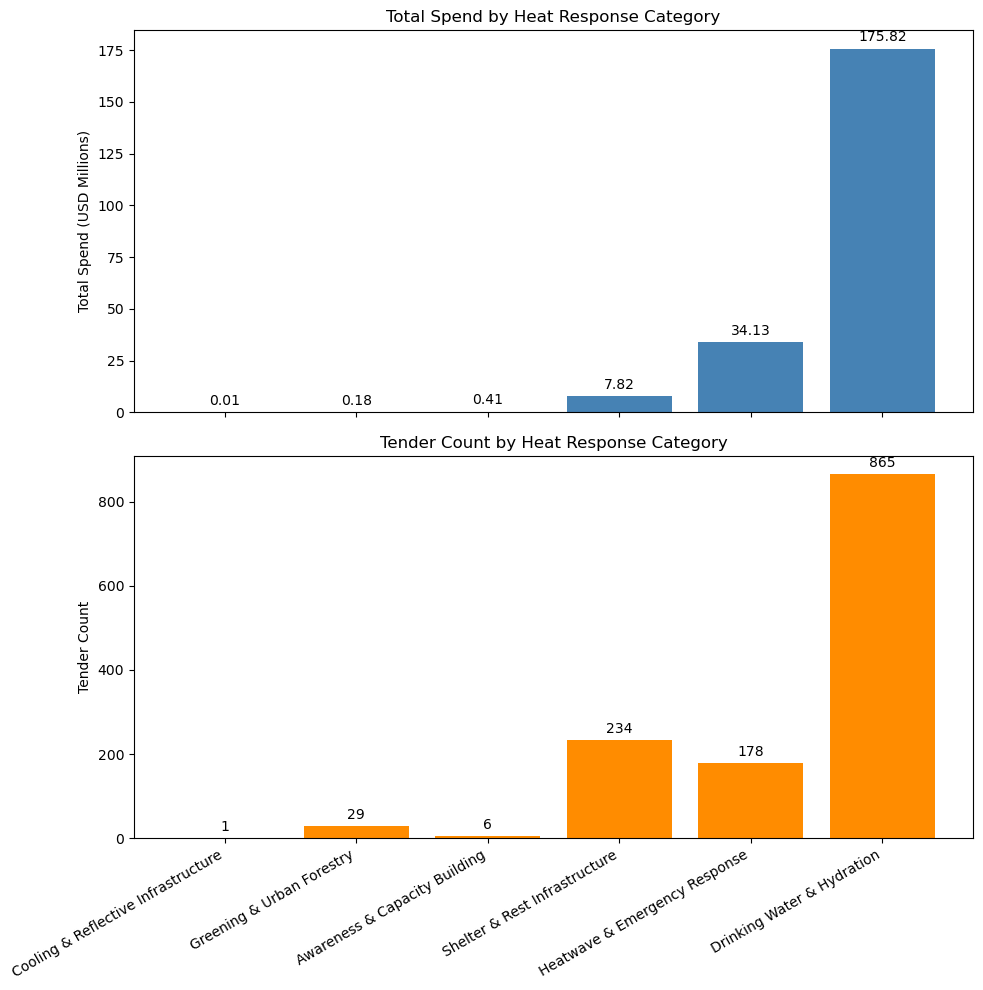

In [10]:
import matplotlib.pyplot as plt

summary = tenders.groupby('Heat Response - Themes')['Awarded Value USD'].agg(
    total_spend='sum', tender_count='count'
).sort_values('total_spend')

summary['total_spend_millions'] = summary['total_spend'] / 1e6

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

bars1 = ax1.bar(summary.index, summary['total_spend_millions'], color='steelblue')
ax1.set_ylabel('Total Spend (USD Millions)')
ax1.set_title('Total Spend by Heat Response Category')
ax1.bar_label(bars1, fmt='%.2f', padding=3)

bars2 = ax2.bar(summary.index, summary['tender_count'], color='darkorange')
ax2.set_ylabel('Tender Count')
ax2.set_title('Tender Count by Heat Response Category')
ax2.bar_label(bars2, padding=3)
ax2.set_xticklabels(summary.index, rotation=30, ha='right')

fig.tight_layout()
plt.show()


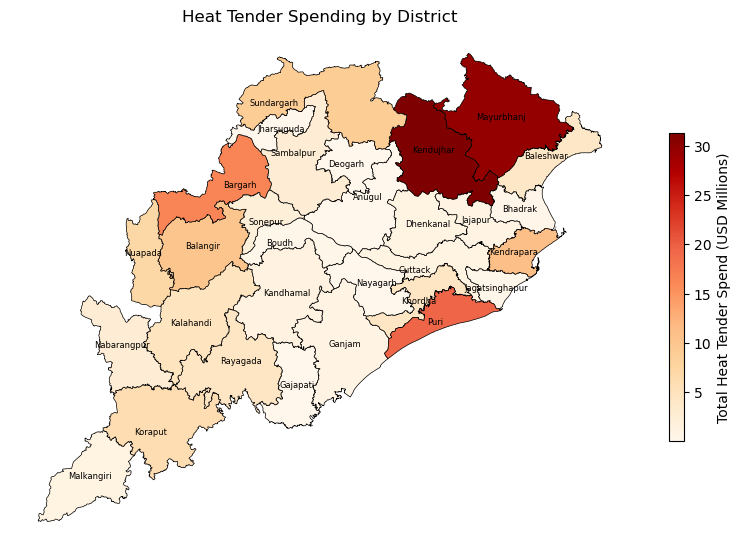

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt

district_geo = gpd.read_file(
    '/Users/saurabhlevin/Deployment/IDS-DRR_Heat/Heat-odisha/data_extractor/assets/district.geojson'
)
district_geo = district_geo.dissolve(by='dtname', as_index=False)

district_spend = (
    tenders.groupby('DISTRICT_FINALISED')['Awarded Value USD']
    .sum()
    .div(1e6)
    .reset_index(name='total_spend_millions')
)

district_map = district_geo.merge(
    district_spend, left_on='dtname', right_on='DISTRICT_FINALISED', how='left'
)

fig, ax = plt.subplots(figsize=(10, 10))
district_map.plot(
    column='total_spend_millions',
    cmap='OrRd',
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    legend_kwds={
        'label': 'Total Heat Tender Spend (USD Millions)',
        'shrink': 0.4,
    },
    missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    ax=ax,
)

for _, row in district_map.iterrows():
    centroid = row['geometry'].representative_point()
    ax.annotate(
        row['dtname'],
        xy=(centroid.x, centroid.y),
        ha='center', va='center',
        fontsize=6,
    )

ax.set_title('Heat Tender Spending by District')
ax.axis('off')
plt.show()


In [12]:
import json
import re

pd.set_option('display.max_colwidth', None)

# Build a town -> district gazetteer from the urban boundaries file, since
# DISTRICT_FINALISED is sometimes blank even though the tender title/location
# names a town we can resolve (e.g. "Rourkela" -> Sundargarh, "Vyasanagar" -> Jajapur).
with open('/Users/saurabhlevin/Deployment/IDS-DRR_Heat/Heat-odisha/Maps/od_ids-drr_shapefiles/od_urban_final.geojson') as f:
    urban = json.load(f)

def clean_town(name):
    return re.sub(r'\(.*?\)', '', name or '').strip().lower()

town_to_district = {}
for feat in urban['features']:
    props = feat['properties']
    dtname = props.get('DTNAME')
    if not dtname:
        continue
    for key in ('VILNAM_SOI', 'VILNAME11'):
        town = clean_town(props.get(key))
        if town:
            town_to_district[town] = dtname.title()

# Old/alternate spellings and transliterations that don't match the gazetteer
# strings but show up in tender text.
DISTRICT_ALIASES = {
    'keonjhar': 'Kendujhar', 'balasore': 'Baleshwar',
    'rourkela': 'Sundargarh', 'vyasanagar': 'Jajapur',
}

KNOWN_DISTRICTS = sorted(tenders['DISTRICT_FINALISED'].dropna().unique())

def closest_district(row):
    if pd.notna(row['DISTRICT_FINALISED']):
        return row['DISTRICT_FINALISED']
    haystack = ' '.join(
        str(row.get(c, '')) for c in ('location', 'tender_title', 'Work Description')
    ).lower()
    for town, district in town_to_district.items():
        if town in haystack:
            return district
    for alias, district in DISTRICT_ALIASES.items():
        if alias in haystack:
            return district
    for district in KNOWN_DISTRICTS:
        if district.lower() in haystack:
            return district
    return np.nan  # no usable match found

tenders['District (best match)'] = tenders.apply(closest_district, axis=1)

top_n = 10
cols = ['Tender ID', 'tender_title', 'Department', 'Awarded Value', 'Awarded Value USD',
        'District (best match)', 'Heat Response - Themes', 'month']

biggest_tenders = tenders.sort_values('Awarded Value', ascending=False).head(top_n)[cols]
biggest_tenders


,Tender ID,tender_title,Department,Awarded Value,Awarded Value USD,District (best match),Heat Response - Themes,month
978,2021_WATCO_65674_1,Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Joda and Champua on Engineering Procurement and Construction (EPC) Contract Including Operation and Maintenance for a Period of Three Years,WATCO Bhubaneswar,1.038548e+09,1.101323e+07,Kendujhar,Drinking Water & Hydration,2021_09
979,2021_WATCO_65675_1,Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Barbil on Engineering Procurement and Construction (EPC) Contract Including Operation and Maintenance for a Period of Three Years,WATCO Bhubaneswar,9.046627e+08,9.593454e+06,Kendujhar,Drinking Water & Hydration,2021_09
62,2021_WATCO_65679_1,Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Rourkela on Engineering Procurement and Construction (EPC) Contract Including Operation and Maintenance for a Period of Three Years,WATCO Bhubaneswar,8.591567e+08,9.110888e+06,Sundargarh,Drinking Water & Hydration,2021_08
976,2021_WATCO_65648_1,Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Keonjhar on Engineering Procurement and Construction (EPC) Contract Including Operation and Maintenance for a Period of Three Years,WATCO Bhubaneswar,8.246235e+08,8.744682e+06,Kendujhar,Drinking Water & Hydration,2021_09
61,2021_WATCO_65678_1,Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Baripada on Engineering Procurement and Construction (EPC) Contract Including Operation and Maintenance for a Period of Three Years,WATCO Bhubaneswar,7.693977e+08,8.159042e+06,Mayurbhanj,Drinking Water & Hydration,2021_08
59,2021_WATCO_65676_1,Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Karanjia and Udala on Engineering Procurement and Construction (EPC) Contract Including Operation and Maintenance for a Period of Three Years,WATCO Bhubaneswar,7.376667e+08,7.822553e+06,Mayurbhanj,Drinking Water & Hydration,2021_08
977,2021_WATCO_65673_1,Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Anandapur on Engineering Procurement and Construction (EPC) Contract Including Operation and Maintenance for a Period of Three Years,WATCO Bhubaneswar,7.279603e+08,7.719621e+06,Kendujhar,Drinking Water & Hydration,2021_09
975,2021_WATCO_65646_1,Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Vyasanagar on Engineering Procurement and Construction (EPC) Contract Including Operation and Maintenance for a Period of Three Years.,WATCO Bhubaneswar,6.941800e+08,7.361400e+06,Jajapur,Drinking Water & Hydration,2021_09
63,2021_WATCO_65680_1,"Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Sundargarh, Biramitrapur and Rajgangpur on (EPC) Contract Including Operation and Maintenance for a Period of Three Years",WATCO Bhubaneswar,6.703972e+08,7.109196e+06,Sundargarh,Drinking Water & Hydration,2021_08
60,2021_WATCO_65677_1,Improvement of water supply to provide safe and clean drinking water conforming to drink from tap quality to Rairangpur on Engineering Procurement and Construction (EPC) Contract Including Operation and Maintenance for a Period of Three Years,WATCO Bhubaneswar,4.218941e+08,4.473956e+06,Mayurbhanj,Drinking Water & Hydration,2021_08


## High-risk districts for heat: Assam & Odisha

Uses the composite risk scores from each state's `RiskScoreModel` pipeline
(`district_final_risk_score.csv`), where `heat-risk-score` is a TOPSIS-based
combination of `heat-hazard` (heat days/LST), `exposure` (population at risk),
`vulnerability` (sensitivity + coping capacity), and, for Odisha,
`government-response` (tender spend as a coping offset) — each scored on a 1-5 scale.

In [13]:
odisha_risk = pd.read_csv(
    '/Users/saurabhlevin/Deployment/IDS-DRR_Heat/Heat-odisha/RiskScoreModel/data/district_final_risk_score.csv'
)
assam_risk = pd.read_csv(
    '/Users/saurabhlevin/Deployment/IDS-DRR_Heat/Heat-assam/RiskScoreModel/data/district_final_risk_score.csv'
)

odisha_risk = odisha_risk.rename(columns={'dtname': 'district_name'})
assam_risk = assam_risk[assam_risk['district'] != '0'].copy()  # '0' is an unmatched/junk row
assam_risk['district_name'] = assam_risk['district'].str.title()

indicator_cols = ['heat-hazard', 'exposure', 'vulnerability', 'government-response']

def district_summary(df, state):
    cols = [c for c in indicator_cols if c in df.columns]
    summary = df.groupby('district_name')[cols + ['heat-risk-score']].mean().round(2)
    summary.insert(0, 'state', state)
    return summary.sort_values('heat-risk-score', ascending=False)

odisha_district_summary = district_summary(odisha_risk, 'Odisha')
assam_district_summary = district_summary(assam_risk, 'Assam')

print('=== Odisha: top 10 highest-risk districts (mean across all months) ===')
display(odisha_district_summary.head(10))
print('\n=== Assam: top 10 highest-risk districts (mean across all months) ===')
display(assam_district_summary.head(10))

=== Odisha: top 10 highest-risk districts (mean across all months) ===


,state,heat-hazard,exposure,vulnerability,government-response,heat-risk-score
district_name,,,,,,
Jajapur,Odisha,3.05,3.76,4.52,3.02,4.38
Kalahandi,Odisha,2.97,3.00,4.52,3.02,4.30
Kendujhar,Odisha,3.06,3.00,3.76,2.76,3.76
Bhadrak,Odisha,2.98,4.52,2.76,3.19,3.62
Dhenkanal,Odisha,2.98,3.57,2.24,3.05,3.00
Anugul,Odisha,3.00,3.57,1.24,3.24,2.97
Deogarh,Odisha,3.00,2.24,1.48,3.24,2.81
Rayagada,Odisha,2.98,2.24,1.71,2.95,2.79
Jagatsinghapur,Odisha,2.98,3.00,1.24,3.16,2.78



=== Assam: top 10 highest-risk districts (mean across all months) ===


,state,heat-hazard,exposure,vulnerability,heat-risk-score
district_name,,,,,
Tinsukia,Assam,3.18,4.0,5.0,4.42
Karimganj,Assam,3.18,4.0,5.0,4.42
Karbi Anglong,Assam,3.10,3.0,5.0,4.32
Hojai,Assam,2.97,5.0,5.0,4.32
Udalguri,Assam,3.16,2.0,5.0,3.76
Sonitpur,Assam,3.13,5.0,4.0,3.73
Dibrugarh,Assam,3.08,3.0,4.0,3.68
Lakhimpur,Assam,3.06,3.0,4.0,3.66
Golaghat,Assam,3.05,3.0,4.0,3.65


In [14]:
def indicator_correlations(df, state):
    cols = [c for c in indicator_cols if c in df.columns]
    corr = df[cols + ['heat-risk-score']].corr()['heat-risk-score'].drop('heat-risk-score')
    return corr.sort_values(ascending=False).rename(state)

corr_table = pd.concat(
    [indicator_correlations(odisha_risk, 'Odisha'), indicator_correlations(assam_risk, 'Assam')],
    axis=1,
).round(2)

print('=== Correlation of each indicator with heat-risk-score ===')
corr_table

=== Correlation of each indicator with heat-risk-score ===


,Odisha,Assam
vulnerability,0.59,0.76
government-response,0.35,NaN
heat-hazard,0.29,0.37
exposure,0.21,0.32


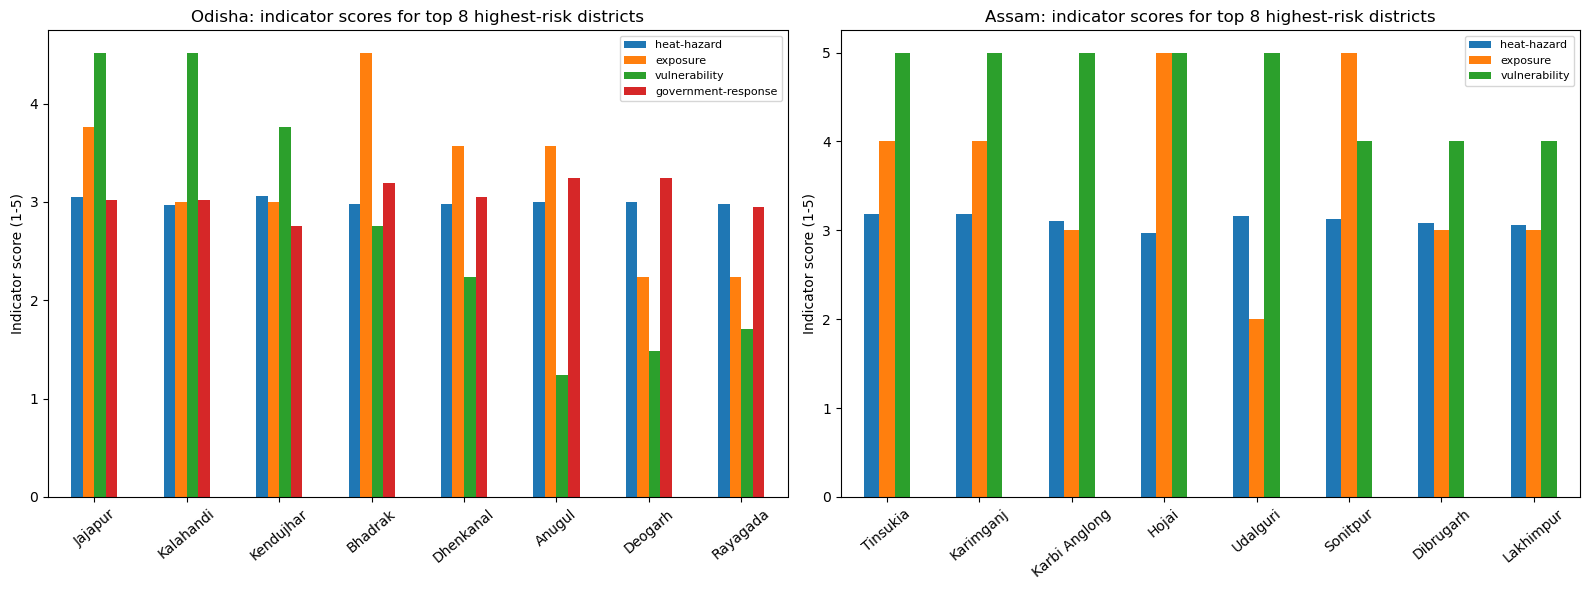

In [15]:
top_n = 8

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, summary, state in [
    (axes[0], odisha_district_summary, 'Odisha'),
    (axes[1], assam_district_summary, 'Assam'),
]:
    cols = [c for c in indicator_cols if c in summary.columns]
    top = summary.head(top_n)[cols]
    top.plot(kind='bar', ax=ax)
    ax.set_title(f'{state}: indicator scores for top {top_n} highest-risk districts')
    ax.set_ylabel('Indicator score (1-5)')
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=40)

fig.tight_layout()
plt.show()